# Two-Stage Ekman Emotion Classification

**Pipeline:**
```
Text → [Stage 1: neutral vs emotion] → emotion → [Stage 2: 6-class multi-label] → anger/joy/...
                                      → neutral ─────────────────────────────── → neutral
```


**Output structure:**
```
<run_base_dir>/run_2_stage/
  electra+deberta/           ← first run
    checkpoints/             ← stage1_best.pth, stage2_best.pth
    logs/                    ← training_log_stage1.csv, stage2.csv
    results/stage1/          ← report, metrics, charts
    results/stage2/
    results/end2end/
  electra+deberta_2/         ← second run (no overwrite)
```

## 0. Setup

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/convitom/NLP_Emotion_Group_14.git

Cloning into 'NLP_Emotion_Group_14'...
remote: Enumerating objects: 585, done.
remote: Counting objects: 100% (277/277), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 585 (delta 104), reused 161 (delta 36), pack-reused 308 (from 1)
Receiving objects: 100% (585/585), 11.36 MiB | 12.13 MiB/s, done.
Resolving deltas: 100% (257/257), done.


In [ ]:
!pip install torch transformers scikit-learn pandas numpy matplotlib tqdm nlpaug pyyaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 10.8 MB/s eta 0:00:00


In [ ]:
import os, sys
import torch

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
cd /content/NLP_Emotion_Group_14/2-stage

/content/NLP_Emotion_Group_14/2-stage


## 1. Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

CONFIG_PATH = 'config/config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
df = pd.read_csv(os.path.join(cfg['data']['data_dir'], cfg['data']['train_file']))
emotions = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
counts   = df[emotions].sum().sort_values(ascending=False)

n_emotion = (df[emotions].sum(axis=1) > 0).sum()
n_neutral = len(df) - n_emotion

print(f'Total samples : {len(df):,}')
print(f'has_emotion   : {n_emotion:,} ({n_emotion/len(df)*100:.1f}%)')
print(f'neutral       : {n_neutral:,} ({n_neutral/len(df)*100:.1f}%)')
print(f'\nEmotion counts (sorted):')
for name, c in counts.items():
    print(f'  {name:<12}: {int(c):>6}')

Total samples : 50,248
has_emotion   : 35,751 (71.1%)
neutral       : 14,497 (28.9%)

Emotion counts (sorted):
  joy         :  19794
  anger       :   7813
  surprise    :   5418
  sadness     :   5392
  disgust     :   3366
  fear        :   1941


## 2. Stage 1 Training

**Task:** Binary — detect if a text has any emotion  


CONFIG

In [ ]:
# Output
cfg['run_base_dir'] = "/content/drive/MyDrive" # Đường dẫn lưu kết quả

# Data
cfg['data']['data_dir'] = "data/"
cfg['data']['train_file'] = "data1_train.csv"
cfg['data']['val_file'] = "data1_val.csv"
cfg['data']['test_file'] = "data1_test.csv"

cfg['data']['auto_split'] = False
cfg['data']['val_ratio'] = 0.10
cfg['data']['test_ratio'] = 0.10

cfg['data']['max_length'] = 128
cfg['data']['seed'] = 42

# Stage 1 — Binary: Neutral vs Emotion-
cfg['stage1']['model']['name'] = "electra" # electra / roberta / bert
cfg['stage1']['model']['dropout'] = 0.1

cfg['stage1']['training']['epochs'] = 10
cfg['stage1']['training']['batch_size'] = 32
cfg['stage1']['training']['lr'] = 2.0e-5
cfg['stage1']['training']['weight_decay'] = 0.01

cfg['stage1']['training']['optimizer'] = "adamw"
cfg['stage1']['training']['scheduler'] = "cosine_warmup"
cfg['stage1']['training']['warmup_ratio'] = 0.10

cfg['stage1']['training']['early_stopping_patience'] = 5
cfg['stage1']['training']['threshold'] = 0.5

cfg['stage1']['training']['loss'] = "bce_weighted"
cfg['stage1']['training']['sample'] = "none"
cfg['stage1']['training']['ratio'] = 1.0


# Stage 2 — Multi-Label: 6 Ekman Emotions
cfg['stage2']['model']['name'] = "roberta" # electra / roberta / bert
cfg['stage2']['model']['dropout'] = 0.2

cfg['stage2']['training']['epochs'] = 15
cfg['stage2']['training']['batch_size'] = 32
cfg['stage2']['training']['lr'] = 2.0e-5
cfg['stage2']['training']['weight_decay'] = 0.05

cfg['stage2']['training']['optimizer'] = "adamw"
cfg['stage2']['training']['scheduler'] = "cosine_warmup"
cfg['stage2']['training']['warmup_ratio'] = 0.10

cfg['stage2']['training']['early_stopping_patience'] = 5
cfg['stage2']['training']['threshold'] = 0.5

cfg['stage2']['training']['loss'] = "asymmetric"

# ASL parameters
cfg['stage2']['training']['asl_gamma_pos'] = 0.0
cfg['stage2']['training']['asl_gamma_neg'] = 2.0
cfg['stage2']['training']['asl_clip'] = 0.05

# Augmentation
cfg['stage2']['training']['augment'] = True

# Inference
cfg['stage2']['training']['inference_window'] = 1
cfg['stage1']['training']['inference_window'] = 1

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, allow_unicode=True)

In [ ]:
from src.train import train

s1_result = train(config_path=CONFIG_PATH, stage='stage1')

RUN_DIR = s1_result['run_dir']   # reuse same run dir for stage2 + test
print(f'\nRun directory: {RUN_DIR}')
print(f'Best epoch   : {s1_result["best_epoch"]}')
for k, v in s1_result['best_metrics'].items():
    print(f'  {k}: {v:.4f}')


  New run : electra+roberta
  Path    : /content/drive/MyDrive/run_2_stage/electra+roberta
[train] stage=stage1  device=cuda  AMP=True (float16)


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch   8/10  tr_loss=0.0417  val_loss=0.9423  acc=0.7858  f1=0.8594  p=0.8118  r=0.9129  lr=2.35e-06  [400s]
  · No improve 2/5  (val_f1=0.8594, best=0.8621)


Epoch 9/10 [train]:   0%|          | 0/1571 [00:00<?, ?batch/s]

Epoch   9/10  tr_loss=0.0317  val_loss=0.9863  acc=0.7850  f1=0.8583  p=0.8137  r=0.9081  lr=6.08e-07  [400s]
  · No improve 3/5  (val_f1=0.8583, best=0.8621)


Epoch 10/10 [train]:   0%|          | 0/1571 [00:00<?, ?batch/s]


[WARNING] NaN/Inf gradient — skipping batch, resetting scaler
Epoch  10/10  tr_loss=0.0276  val_loss=1.0030  acc=0.7860  f1=0.8590  p=0.8142  r=0.9090  lr=1.21e-11  [403s]
  · No improve 4/5  (val_f1=0.8590, best=0.8621)

[train] STAGE1 done — best val_f1=0.8621 @ epoch 6
        accuracy=0.7902
        f1=0.8621
        precision=0.8153
        recall=0.9147
[train] Log → /content/drive/MyDrive/run_2_stage/electra+roberta/logs/training_log_stage1.csv

Run directory: /content/drive/MyDrive/run_2_stage/electra+roberta
Best epoch   : 6
  accuracy: 0.7902
  f1: 0.8621
  precision: 0.8153
  recall: 0.9147


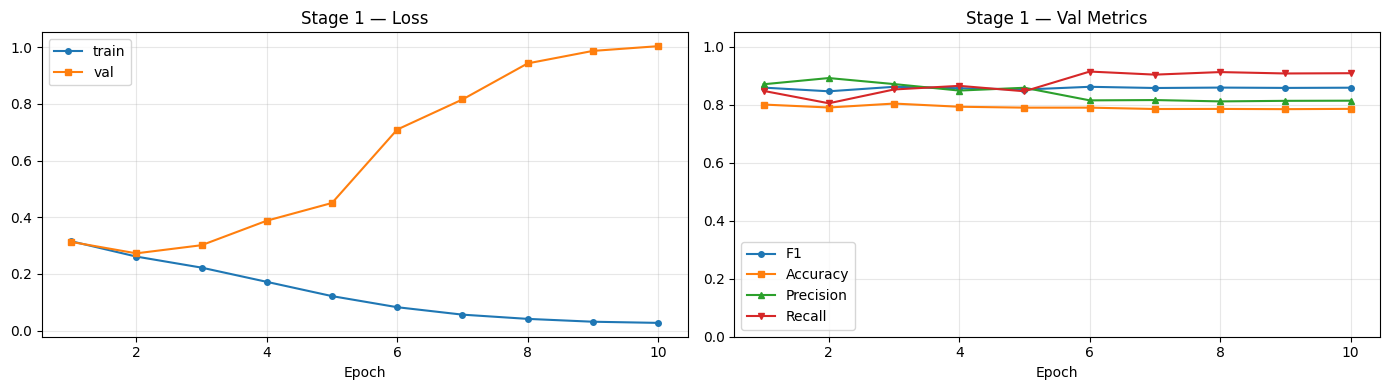

In [ ]:
log1 = pd.read_csv(s1_result['log_path'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(log1.epoch, log1.train_loss, label='train', marker='o', ms=4)
ax1.plot(log1.epoch, log1.val_loss,   label='val',   marker='s', ms=4)
ax1.set_title('Stage 1 — Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(log1.epoch, log1.val_f1,        label='F1',        marker='o', ms=4)
ax2.plot(log1.epoch, log1.val_accuracy,  label='Accuracy',  marker='s', ms=4)
ax2.plot(log1.epoch, log1.val_precision, label='Precision', marker='^', ms=4)
ax2.plot(log1.epoch, log1.val_recall,    label='Recall',    marker='v', ms=4)
ax2.set_title('Stage 1 — Val Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Stage 2 Training

**Task:** Multi-label 6 Ekman emotions (emotion-only samples)  


In [ ]:
# ── Optional overrides ────────────────────────────────────────────────────────
# cfg['stage2']['model']['name'] = 'deberta'   # deberta | roberta | electra | bert
# cfg['stage2']['training']['batch_size'] = 16   # reduce if OOM
# cfg['stage2']['training']['epochs'] = 20

s2_result = train(config_path=CONFIG_PATH, stage='stage2', run_dir=RUN_DIR)

print(f'\nBest epoch  : {s2_result["best_epoch"]}')
for k, v in s2_result['best_metrics'].items():
    print(f'  {k}: {v:.4f}')


  Continuing: electra+roberta  stage=stage2
[train] stage=stage2  device=cuda  AMP=True (float16)
[DataLoader] stage=stage2  backbone=roberta  num_workers=2
[DataLoader] Running median-based synonym augmentation (nlpaug)...


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

[Augmentation] class=disgust      n_c=  3366 → +2039 samples (target median=5405)


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

[Augmentation] class=fear         n_c=  1941 → +3464 samples (target median=5405)
[Augmentation] class=sadness      n_c=  5392 → +13 samples (target median=5405)
[DataLoader] Stage 2 training set after augmentation: 41267 samples

[DataLoader] pos_weight (stage2, post-augmentation):
    anger       : 3.17
    disgust     : 5.57
    fear        : 6.24
    joy         : 1.01
    sadness     : 4.75
    surprise    : 6.26
[DataLoader] Train=41267  Val=4526  Test=6803


...


[WARNING] NaN/Inf gradient — skipping batch, resetting scaler
Epoch  13/15  tr_loss=0.0211  val_loss=0.5257  micro_f1=0.7835  macro_f1=0.7189  w_f1=0.7874  lr=1.07e-06  [335s]
  · No improve 3/5  (val_macro_f1=0.7189, best=0.7199)


Epoch 14/15 [train]:   0%|          | 0/1290 [00:00<?, ?batch/s]


[WARNING] NaN/Inf gradient — skipping batch, resetting scaler
Epoch  14/15  tr_loss=0.0195  val_loss=0.5324  micro_f1=0.7830  macro_f1=0.7168  w_f1=0.7863  lr=2.73e-07  [335s]
  · No improve 4/5  (val_macro_f1=0.7168, best=0.7199)


Epoch 15/15 [train]:   0%|          | 0/1290 [00:00<?, ?batch/s]

Epoch  15/15  tr_loss=0.0184  val_loss=0.5330  micro_f1=0.7827  macro_f1=0.7159  w_f1=0.7862  lr=1.32e-11  [335s]
  · No improve 5/5  (val_macro_f1=0.7159, best=0.7199)
[train] Early stopping at epoch 15 (5 consecutive epochs without improvement on val_macro_f1).

[train] STAGE2 done — best val_macro_f1=0.7199 @ epoch 10
        micro_f1=0.7821
        macro_f1=0.7199
        weighted_f1=0.7849
[train] Log → /content/drive/MyDrive/run_2_stage/electra+roberta/logs/training_log_stage2.csv

Best epoch  : 10
  micro_f1: 0.7821
  macro_f1: 0.7199
  weighted_f1: 0.7849


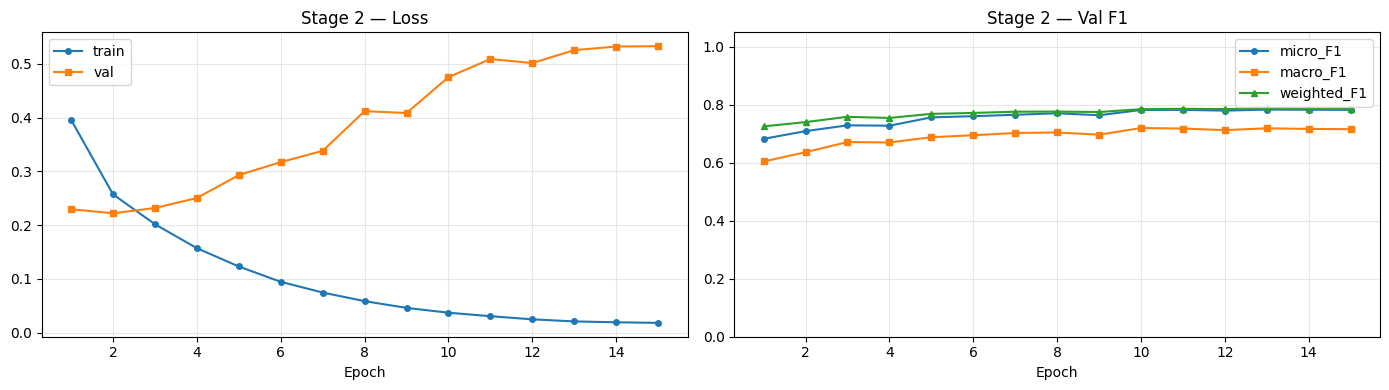

In [ ]:
log2 = pd.read_csv(s2_result['log_path'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(log2.epoch, log2.train_loss, label='train', marker='o', ms=4)
ax1.plot(log2.epoch, log2.val_loss,   label='val',   marker='s', ms=4)
ax1.set_title('Stage 2 — Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(log2.epoch, log2.val_micro_f1,    label='micro_F1',    marker='o', ms=4)
ax2.plot(log2.epoch, log2.val_macro_f1,    label='macro_F1',    marker='s', ms=4)
ax2.plot(log2.epoch, log2.val_weighted_f1, label='weighted_F1', marker='^', ms=4)
ax2.set_title('Stage 2 — Val F1')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluate Stage 1

In [ ]:
from src.test import evaluate_stage1

s1_metrics = evaluate_stage1(config_path=CONFIG_PATH, run_dir=RUN_DIR)

print(f'Accuracy     : {s1_metrics["accuracy"]:.4f}')
print(f'F1 (emotion) : {s1_metrics["f1"]:.4f}')
print(f'Macro F1     : {s1_metrics["macro_f1"]:.4f}')
print(f'Best threshold: {s1_metrics["best_threshold"]:.2f}')


  Stage 1 Evaluation — Neutral vs Has-Emotion
  Inference: sentence splitting + context window=1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[test] Loaded stage1 checkpoint  epoch=6  val_f1=0.8621
[DataLoader] stage=stage1  backbone=electra  num_workers=2
[DataLoader] pos_weight (stage1): 0.41
[DataLoader] Train=50248  Val=6312  Test=8686

[test] Sentence-level inference on validation set...
[test] Best threshold: 0.35  val_F1=0.8627

[test] Sentence-level inference on test set...

  Accuracy    : 0.8305
  F1 (emotion): 0.8969
  Precision   : 0.8565
  Recall      : 0.9413
  Macro F1    : 0.7104
              precision    recall  f1-score   support

     neutral       0.67      0.43      0.52      1883
 has_emotion       0.86      0.94      0.90      6803

    accuracy                           0.83      8686
   macro avg       0.76      0.69      0.71      8686
weighted avg       0.82      0.83      0.82      8686

[test] Saved → /content/drive/MyDrive/run_2_stage/electra+roberta/results/stage1
Accuracy     : 0.8305
F1 (emotion) : 0.8969
Macro F1     : 0.7104
Best threshold: 0.35


## 5. Evaluate Stage 2

In [ ]:
from src.test import evaluate_stage2

s2_metrics = evaluate_stage2(config_path=CONFIG_PATH, run_dir=RUN_DIR)

print(f'Micro  F1    : {s2_metrics["micro_f1"]:.4f}')
print(f'Macro  F1    : {s2_metrics["macro_f1"]:.4f}')
print(f'Weighted F1  : {s2_metrics["weighted_f1"]:.4f}')
print(f'Subset Acc   : {s2_metrics["subset_accuracy"]:.4f}')


  Stage 2 Evaluation — 6 Ekman Emotions
  Inference: sentence splitting + context window=1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[test] Loaded stage2 checkpoint  epoch=10  val_macro_f1=0.7199
[DataLoader] stage=stage2  backbone=roberta  num_workers=2
[DataLoader] Running median-based synonym augmentation (nlpaug)...


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

[Augmentation] class=disgust      n_c=  3366 → +2039 samples (target median=5405)


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

[Augmentation] class=fear         n_c=  1941 → +3464 samples (target median=5405)
[Augmentation] class=sadness      n_c=  5392 → +13 samples (target median=5405)
[DataLoader] Stage 2 training set after augmentation: 41267 samples

[DataLoader] pos_weight (stage2, post-augmentation):
    anger       : 3.17
    disgust     : 5.57
    fear        : 6.24
    joy         : 1.01
    sadness     : 4.75
    surprise    : 6.26
[DataLoader] Train=41267  Val=4526  Test=6803

[test] Sentence-level inference on validation set...
[test] Per-class optimal thresholds (val):
  anger       : t=0.70  val_F1=0.7258
  disgust     : t=0.85  val_F1=0.6717
  fear        : t=0.90  val_F1=0.7419
  joy         : t=0.70  val_F1=0.9037
  sadness     : t=0.85  val_F1=0.6706
  surprise    : t=0.90  val_F1=0.6731

[test] Sentence-level inference on test set...

  Micro  F1    : 0.7733
  Macro  F1    : 0.7266
  Weighted F1  : 0.7711
  Hamming Loss : 0.1067
  Subset Acc   : 0.5983
              precision    recall  f1-

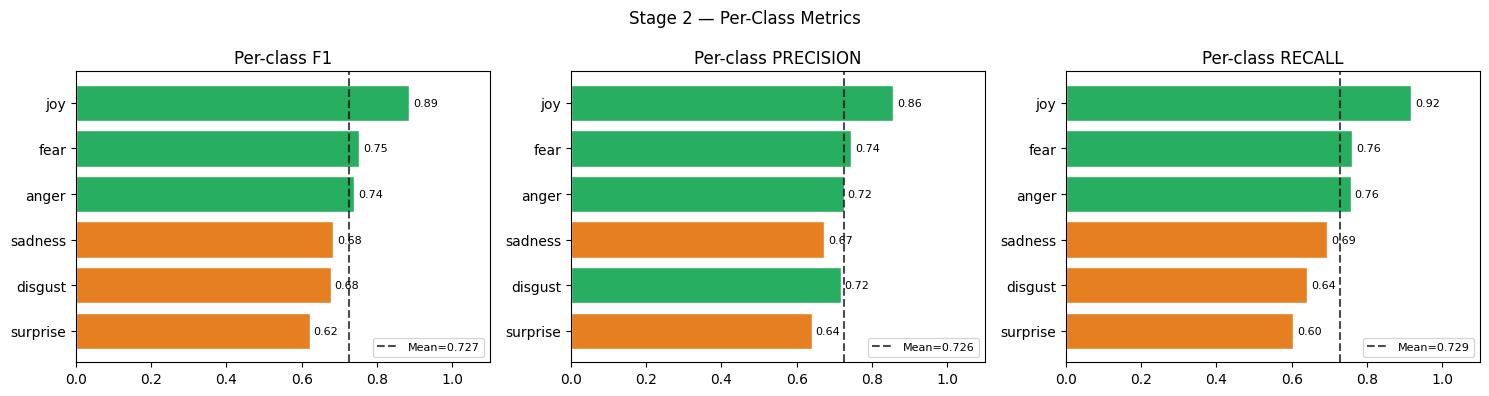

,threshold,precision,recall,f1,support
emotion,,,,,
surprise,0.90,0.6397,0.6038,0.6212,800
disgust,0.85,0.7165,0.6407,0.6765,1219
sadness,0.85,0.6726,0.6941,0.6832,1412
anger,0.70,0.7242,0.7566,0.7400,1787
fear,0.90,0.7445,0.7612,0.7528,578
joy,0.70,0.8566,0.9175,0.8860,3699


In [ ]:
# Per-class breakdown
pc = pd.read_csv(os.path.join(s2_metrics['out_dir'], 'stage2_per_class.csv'))
pc = pc.set_index('emotion').sort_values('f1')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['f1', 'precision', 'recall']):
    colors = ['#c0392b' if v < 0.5 else '#e67e22' if v < 0.7 else '#27ae60' for v in pc[col]]
    bars = ax.barh(pc.index, pc[col], color=colors, edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.set_title(f'Per-class {col.upper()}')
    ax.axvline(pc[col].mean(), color='black', linestyle='--', alpha=0.7,
               label=f'Mean={pc[col].mean():.3f}')
    ax.legend(fontsize=8)
    for bar, v in zip(bars, pc[col]):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=8)

plt.suptitle('Stage 2 — Per-Class Metrics', fontsize=12)
plt.tight_layout()
plt.show()
display(pc)

## 6. End-to-End Evaluation (7 classes)

In [ ]:
from src.test import evaluate_end_to_end

e2e = evaluate_end_to_end(config_path=CONFIG_PATH, run_dir=RUN_DIR)

print(f'Micro  F1    : {e2e["micro_f1"]:.4f}')
print(f'Macro  F1    : {e2e["macro_f1"]:.4f}')
print(f'Weighted F1  : {e2e["weighted_f1"]:.4f}')
print(f'Subset Acc   : {e2e["subset_accuracy"]:.4f}')
print(f'Stage1 Acc   : {e2e["stage1_accuracy"]:.4f} (routing quality)')


  End-to-End Evaluation — 7 Classes
  S1 inference window=1  S2 inference window=1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[test] Loaded stage1 checkpoint  epoch=6  val_f1=0.8621


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[test] Loaded stage2 checkpoint  epoch=10  val_macro_f1=0.7199

[test] Stage 1 val inference...
[test] S1 threshold: 0.35

[test] Stage 2 val inference (emotion-only subset)...
[test] S2 thresholds: [0.7, 0.85, 0.9, 0.7, 0.85, 0.9]

[test] Stage 1 test inference (full corpus)...

[test] Stage 2 test inference (full corpus)...

  Micro  F1    : 0.6862
  Macro  F1    : 0.6493
  Weighted F1  : 0.6793
  Hamming Loss : 0.1197
  Subset Acc   : 0.5364
  Stage1 Acc   : 0.8305  Stage1 F1: 0.8969  (routing quality)
              precision    recall  f1-score   support

       anger       0.62      0.71      0.66      1787
     disgust       0.68      0.63      0.66      1219
        fear       0.71      0.75      0.73       578
         joy       0.76      0.88      0.81      3699
     sadness       0.62      0.68      0.65      1412
    surprise       0.48      0.53      0.51       800
     neutral       0.66      0.44      0.53      1883

   micro avg       0.67      0.70      0.69     11378
 

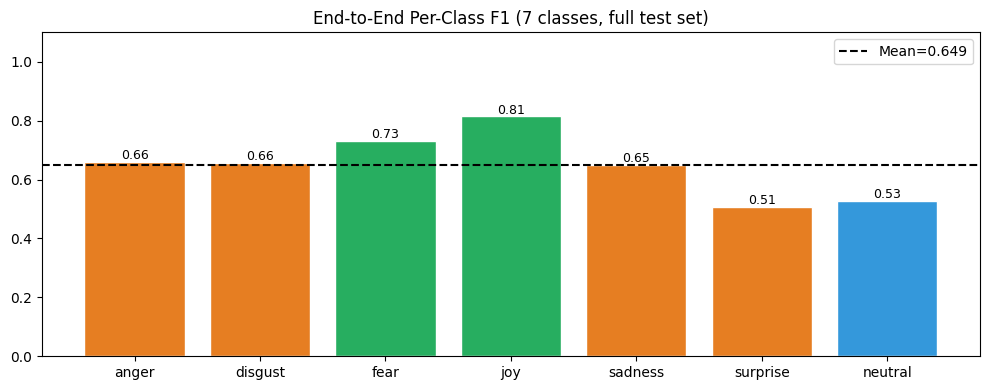

,precision,recall,f1,support
class,,,,
anger,0.6160,0.7073,0.6585,1787
disgust,0.6808,0.6333,0.6562,1219
fear,0.7150,0.7509,0.7325,578
joy,0.7554,0.8832,0.8143,3699
sadness,0.6213,0.6820,0.6502,1412
surprise,0.4830,0.5312,0.5060,800
neutral,0.6598,0.4397,0.5277,1883


In [ ]:
e2e_pc = pd.read_csv(os.path.join(e2e['out_dir'], 'e2e_per_class.csv'))
e2e_pc = e2e_pc.set_index('class')

from src.dataloader import ALL_CLASS_NAMES
colors = ['#3498db' if c == 'neutral' else
          '#c0392b' if e2e_pc.loc[c,'f1'] < 0.5 else
          '#e67e22' if e2e_pc.loc[c,'f1'] < 0.7 else '#27ae60'
          for c in e2e_pc.index]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(e2e_pc.index, e2e_pc['f1'], color=colors, edgecolor='white')
ax.axhline(e2e_pc['f1'].mean(), color='black', linestyle='--',
           label=f'Mean={e2e_pc["f1"].mean():.3f}')
ax.set_ylim(0, 1.1)
ax.set_title('End-to-End Per-Class F1 (7 classes, full test set)')
ax.legend()
for bar, v in zip(bars, e2e_pc['f1']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
display(e2e_pc)

## 7. Results Summary

In [ ]:
print('=' * 62)
print(f'  Run: {s1_result["run_name"]}')
print(f'  Dir: {RUN_DIR}')
print('=' * 62)

print(f'\n Stage 1 — Binary ({cfg["stage1"]["model"]["name"]})')
print(f'   Accuracy    : {s1_metrics["accuracy"]:.4f}')
print(f'   F1 (emotion): {s1_metrics["f1"]:.4f}')
print(f'   Macro F1    : {s1_metrics["macro_f1"]:.4f}')

print(f'\n Stage 2 — 6 Emotions ({cfg["stage2"]["model"]["name"]})')
print(f'   Micro F1    : {s2_metrics["micro_f1"]:.4f}')
print(f'   Macro F1    : {s2_metrics["macro_f1"]:.4f}')
print(f'   Subset Acc  : {s2_metrics["subset_accuracy"]:.4f}')

print(f'\n End-to-End — 7 Classes')
print(f'   Micro F1    : {e2e["micro_f1"]:.4f}')
print(f'   Macro F1    : {e2e["macro_f1"]:.4f}')
print(f'   Weighted F1 : {e2e["weighted_f1"]:.4f}')
print(f'   Subset Acc  : {e2e["subset_accuracy"]:.4f}')
print('=' * 62)

  Run: electra+roberta
  Dir: /content/drive/MyDrive/run_2_stage/electra+roberta

 Stage 1 — Binary (electra)
   Accuracy    : 0.8305
   F1 (emotion): 0.8969
   Macro F1    : 0.7104

 Stage 2 — 6 Emotions (roberta)
   Micro F1    : 0.7733
   Macro F1    : 0.7266
   Subset Acc  : 0.5983

 End-to-End — 7 Classes
   Micro F1    : 0.6862
   Macro F1    : 0.6493
   Weighted F1 : 0.6793
   Subset Acc  : 0.5364


## 8. Inference on New Texts

In [ ]:
import torch
from src.train import build_model
from src.dataloader import BACKBONE_REGISTRY, EMOTION_NAMES
from src.utils import apply_threshold
from transformers import AutoTokenizer

s1_name = cfg['stage1']['model']['name']
s2_name = cfg['stage2']['model']['name']

s1_ckpt = torch.load(os.path.join(RUN_DIR, 'checkpoints', 'stage1_best.pth'),
                     map_location=device, weights_only=False)
s2_ckpt = torch.load(os.path.join(RUN_DIR, 'checkpoints', 'stage2_best.pth'),
                     map_location=device, weights_only=False)

s1_model = build_model(cfg['stage1'], stage='stage1').to(device)
s1_model.load_state_dict(s1_ckpt['model_state'])
s1_model.eval()

s2_model = build_model(cfg['stage2'], stage='stage2').to(device)
s2_model.load_state_dict(s2_ckpt['model_state'])
s2_model.eval()

s1_tok = AutoTokenizer.from_pretrained(BACKBONE_REGISTRY[s1_name]['pretrained'])
s2_tok = AutoTokenizer.from_pretrained(BACKBONE_REGISTRY[s2_name]['pretrained'])

s1_thr = e2e['best_threshold_s1']
s2_thr = e2e['best_thresholds_s2']
cfg['data']['max_length'] = 512
def predict(text):
    ml = cfg['data']['max_length']
    def enc(tok):
        e = tok(text, max_length=ml, padding='max_length', truncation=True, return_tensors='pt')
        return e['input_ids'].to(device), e['attention_mask'].to(device)
    with torch.no_grad():
        p1 = torch.sigmoid(s1_model(*enc(s1_tok))).item()
        if p1 < s1_thr:
            print(f'  [{text[:60]}]')
            print(f'  → NEUTRAL  (p_emotion={p1:.3f})')
            return
        p2 = torch.sigmoid(s2_model(*enc(s2_tok))).cpu().numpy()[0]
        preds = (p2 >= s2_thr).astype(int)
        detected = {n: float(p2[i]) for i,n in enumerate(EMOTION_NAMES) if preds[i]==1}
        if not detected:
            top = EMOTION_NAMES[int(p2.argmax())]
            detected = {top: float(p2.max())}
    print(f'  [{text[:60]}]')
    print(f'  → EMOTION  (p_emotion={p1:.3f})')
    for n, p in sorted(detected.items(), key=lambda x: -x[1]):
        print(f'      {n:<12}: {p:.3f}  {"█"*int(p*20)}')
    print()

tests = [
    "I am so incredibly happy today!",
    "I hate being lied to — it makes me so furious.",
    "The thunder scared me, I couldn't sleep.",
    "I just read an article about climate change.",
    "Wow, that plot twist I did NOT see coming!",
    "My grandmother passed away. I miss her so much.",
    "The report will be submitted by Friday.",
    "I'm disgusted by the corruption in the government.",
    "I'm scared AND angry about what happened.",
    "This is a brilliant article. Trump has completely eroded all trust in diplomacy and negotiation and his policy has been to beat Iran into submission until it surrenders. This includes murdering key members of the regime and turning the previous Ayatollah into a martyr. Now the regime has literally nothing to lose and actively wants conflict to shore up its own position domestically. I just cant believe how foolish Trump could be.",
]
for t in tests:
    predict(t)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [I am so incredibly happy today!]
  → EMOTION  (p_emotion=0.999)
      joy         : 1.000  ███████████████████

  [I hate being lied to — it makes me so furious.]
  → EMOTION  (p_emotion=0.999)
      anger       : 1.000  ███████████████████
      disgust     : 0.975  ███████████████████

  [The thunder scared me, I couldn't sleep.]
  → EMOTION  (p_emotion=0.999)
      fear        : 1.000  ███████████████████

  [I just read an article about climate change.]
  → EMOTION  (p_emotion=0.639)
      joy         : 0.990  ███████████████████

  [Wow, that plot twist I did NOT see coming!]
  → EMOTION  (p_emotion=0.999)
      surprise    : 1.000  ███████████████████

  [My grandmother passed away. I miss her so much.]
  → EMOTION  (p_emotion=0.998)
      sadness     : 1.000  ███████████████████

  [The report will be submitted by Friday.]
  → NEUTRAL  (p_emotion=0.007)
  [I'm disgusted by the corruption in the government.]
  → EMOTION  (p_emotion=0.999)
      disgust     : 1.000  ███████████